MACD only outputed the best accuracy so far

In [1]:
### 1. Import Libraries and Fetch Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import yfinance as yf
import talib as ta

In [2]:
### 2. Indicator Configuration
# Set to True to include, False to exclude
indicator_config = {
    'RSI': False,
    'MACD': True,
    'BollingerBands': False,
    'Volume': False,
}

In [3]:
### 3. Fetching data using yfinance
stock_ticker = 'NVDA'  # Replace with your desired stock ticker
data = yf.Ticker(stock_ticker)
data = data.history(period="2y")
data.reset_index(inplace=True)

In [4]:
### 4. Data Cleaning and Feature Engineering
# Adding Indicators Based on Configuration
if indicator_config['RSI']:
    data['RSI'] = ta.RSI(data['Close'], timeperiod=14)

if indicator_config['MACD']:
    data['MACD'], data['Signal'], _ = ta.MACD(data['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

if indicator_config['BollingerBands']:
    data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(
        data['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
    )

if indicator_config['Volume']:
    data['Volume'] = data['Volume']

# Dropping NaN values due to indicators
data.dropna(inplace=True)

In [5]:
### 5. Splitting Data into Training and Testing Sets
train_size = int(len(data) * 0.8)  # 80% training, 20% testing
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

In [6]:
### 6. Scaling and Preparing Data Based on Included Features
features = ['Close']
if indicator_config['RSI']:
    features.append('RSI')
if indicator_config['MACD']:
    features.extend(['MACD', 'Signal'])
if indicator_config['BollingerBands']:
    features.extend(['UpperBand', 'MiddleBand', 'LowerBand'])
if indicator_config['Volume']:
    features.append('Volume')

# Fit the scaler only on the selected features in training data
sc_train = MinMaxScaler(feature_range=(0, 1))
train_scaled = sc_train.fit_transform(train_data[features])
sc_test = MinMaxScaler(feature_range=(0, 1))
test_scaled = sc_test.fit_transform(test_data[features])

# Preparing training data
X_train = []
y_train = []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i])
    y_train.append(train_scaled[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))

Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.1213
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0191
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0116
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0089
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0082
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0067
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0060
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0044
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0052
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0044
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0042
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0047
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0049
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0047
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0063
E

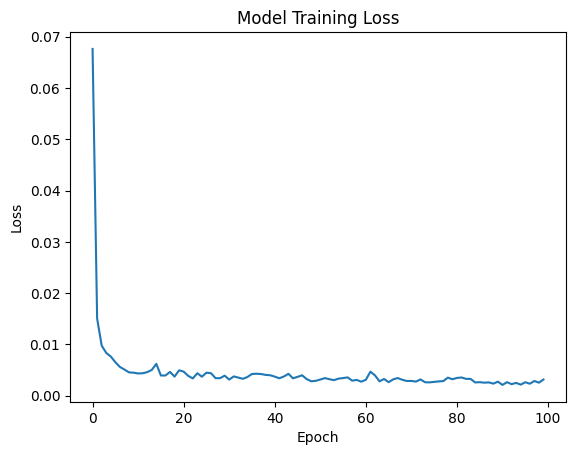

In [7]:
### 7. Building LSTM Model
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

# Compiling the model
regressor.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
history = regressor.fit(X_train, y_train, epochs=100, batch_size=32)

### Plotting Training Loss
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


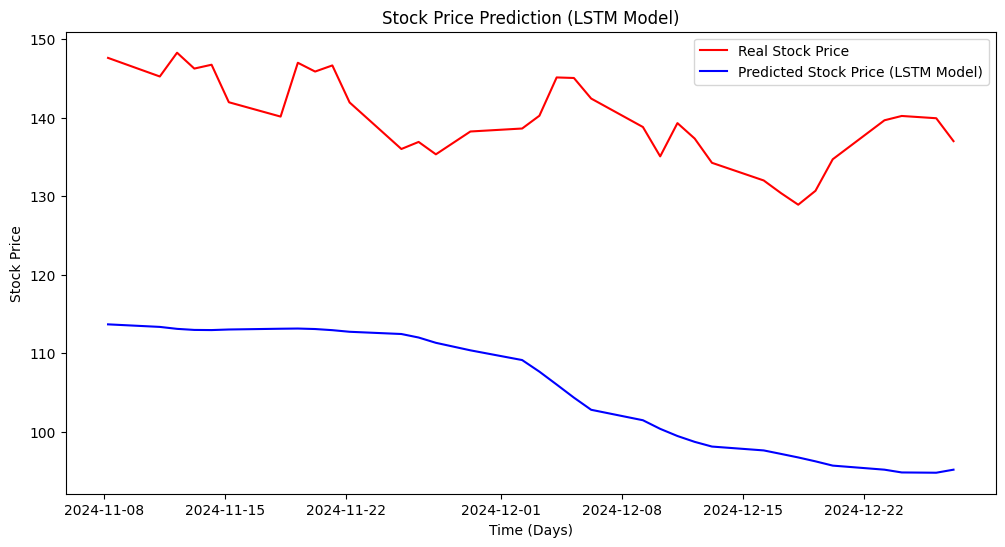

In [8]:
### 8. Preparing Test Data and Making Predictions
# Preparing test data
X_test = []
y_test = test_data['Close'].values[60:]  # Actual 'Close' prices for comparison
for i in range(60, len(test_scaled)):
    X_test.append(test_scaled[i-60:i])
X_test = np.array(X_test, dtype=np.float32)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Predicting stock prices
predicted_stock_price = regressor.predict(X_test, batch_size=32)
predicted_stock_price_expanded = np.zeros((predicted_stock_price.shape[0], len(features)))
predicted_stock_price_expanded[:, 0] = predicted_stock_price.flatten()
predicted_stock_price = sc_train.inverse_transform(predicted_stock_price_expanded)[:, 0]

# Ensure all arrays have the same length
min_length = min(len(test_data['Date'].iloc[60:]), len(y_test), len(predicted_stock_price))
dates_aligned = test_data['Date'].iloc[60:].values[:min_length]
y_test_aligned = y_test[:min_length]
predicted_stock_price_aligned = predicted_stock_price[:min_length]

# Combine arrays and save fitted output
fitted_output = pd.DataFrame({
    'Date': dates_aligned,
    'Real Price': y_test_aligned,
    'Predicted Price': predicted_stock_price_aligned
})
fitted_output.to_csv("Fitted_Data_Output_LSTM_Model.csv", index=False)

# Plotting fitted data
plt.figure(figsize=(12, 6))
plt.plot(dates_aligned, y_test_aligned, color='red', label='Real Stock Price')
plt.plot(dates_aligned, predicted_stock_price_aligned, color='blue', label='Predicted Stock Price (LSTM Model)')
plt.title('Stock Price Prediction (LSTM Model)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [9]:
### 9. Backtesting and Accuracy Assessment
# Calculating trend accuracy
trend_real = np.sign(np.diff(y_test_aligned))  # Actual trends (1 for up, -1 for down, 0 for no change)
trend_predicted = np.sign(np.diff(predicted_stock_price_aligned))  # Predicted trends
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

# Calculating Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_aligned - predicted_stock_price_aligned) / y_test_aligned)) * 100

# Overall accuracy score
overall_accuracy = 100 - mape

# Print metrics
print("Trend Accuracy (LSTM Model): {:.2f}%".format(trend_accuracy))
print("Mean Absolute Percentage Error (MAPE) (LSTM Model): {:.2f}%".format(mape))
print("Overall Accuracy Score (LSTM Model): {:.2f}%".format(overall_accuracy))

Trend Accuracy (LSTM Model): 51.52%
Mean Absolute Percentage Error (MAPE) (LSTM Model): 24.70%
Overall Accuracy Score (LSTM Model): 75.30%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


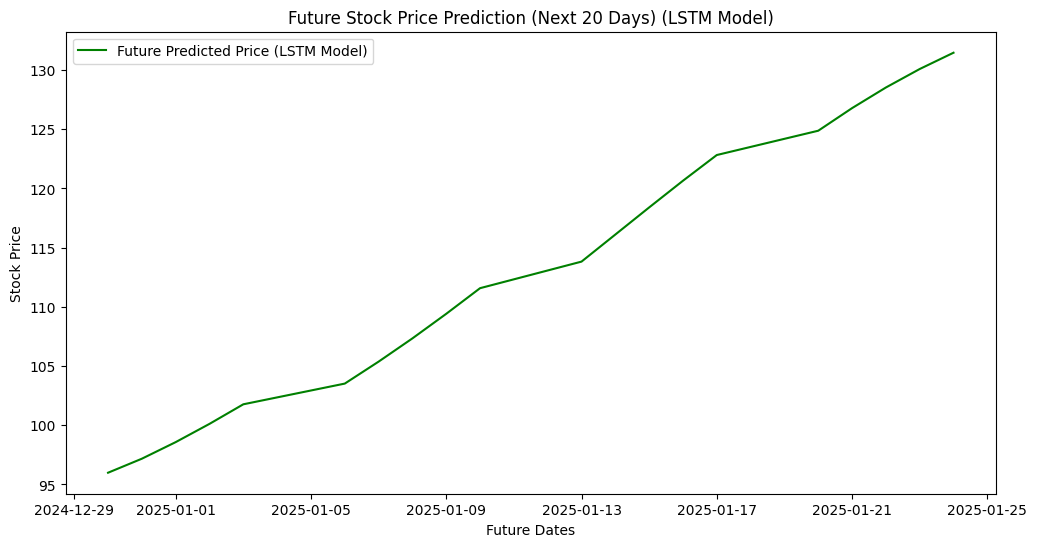

In [10]:
### 10. Future Prediction Logic (20 Days Ahead)
# Starting with the last 60 days of the test set
future_input = test_scaled[-60:]
future_predictions = []

for _ in range(20):
    # Reshape input to match the expected shape
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = regressor.predict(future_input)

    # Append the prediction to the results
    future_predictions.append(future_pred[0, 0])

    # Update the input by appending the prediction and removing the oldest step
    next_step = np.zeros((1, len(features)))
    next_step[0, 0] = future_pred[0, 0]
    future_input = np.vstack([future_input[0, 1:, :], next_step])

# Rescale predictions back to original range
future_predictions = sc_train.inverse_transform(
    np.pad(np.array(future_predictions).reshape(-1, 1), ((0, 0), (0, len(features) - 1)), constant_values=0)
)[:, 0]

# Generate future dates for predictions
future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]

# Save future predictions
future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions
})
future_output.to_csv("Future_Predictions_LSTM_Model.csv", index=False)

# Plotting future predictions
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, color='green', label='Future Predicted Price (LSTM Model)')
plt.title('Future Stock Price Prediction (Next 20 Days) (LSTM Model)')
plt.xlabel('Future Dates')
plt.ylabel('Stock Price')
plt.legend()
plt.show()